In [14]:
import os
# Isso cria as pastas que mostram que você é organizado(a)
for folder in ['data', 'src', 'models']:
    if not os.path.exists(folder):
        os.makedirs(folder)

In [15]:
import pandas as pd
import numpy as np

# Criando dados para o modelo aprender
def gerar_dados(n=1000):
    data = {
        'frequencia': np.random.uniform(0.3, 1.0, n),
        'nota_media': np.random.uniform(0, 10, n),
        'renda_familiar': np.random.choice([1200, 2500, 5000], n),
        'evasao': np.random.choice([0, 1], n)
    }
    df = pd.DataFrame(data)
    # Criando uma lógica real: quem tem nota baixa e falta muito, tende a sair
    df.loc[(df['nota_media'] < 5) & (df['frequencia'] < 0.7), 'evasao'] = 1
    return df

df = gerar_dados()
df.to_csv('data/dados_alunos.csv', index=False) # Salvando na pasta data
print("Arquivo dados_alunos.csv criado dentro da pasta data!")

Arquivo dados_alunos.csv criado dentro da pasta data!


In [16]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import joblib

# 1. Separar dados
X = df.drop('evasao', axis=1)
y = df['evasao']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# 2. Treinar
modelo = RandomForestClassifier(n_estimators=100)
modelo.fit(X_train, y_train)

# 3. Salvar o "cérebro" na pasta de modelos
joblib.dump(modelo, 'models/modelo_evasao.pkl')
print("Sucesso! Modelo treinado e salvo na pasta models.")

Sucesso! Modelo treinado e salvo na pasta models.


/tmp/ipykernel_10975/1599419355.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importância', y='Variável', data=df_importancia, palette='viridis')


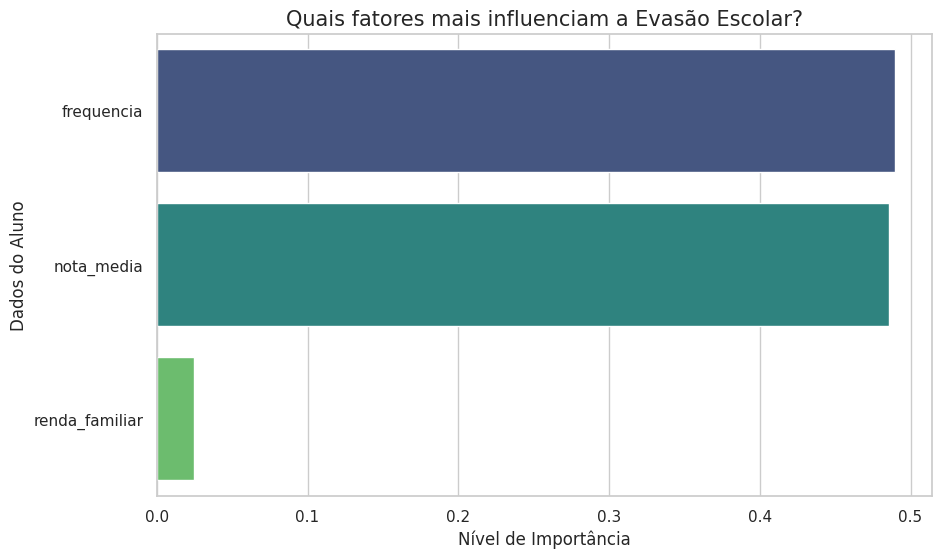

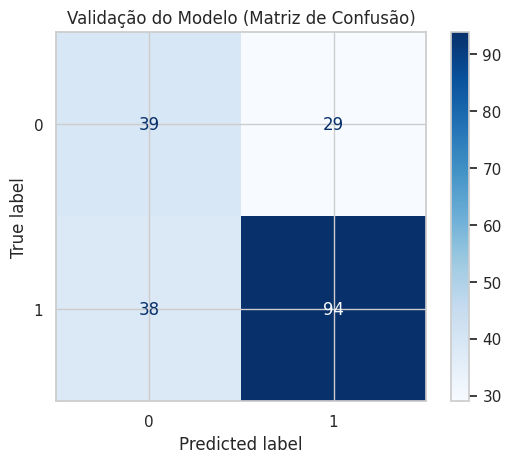

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configurar o visual dos gráficos
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# 2. Criar gráfico de Importância das Variáveis
importances = modelo.feature_importances_
features = X.columns
df_importancia = pd.DataFrame({'Variável': features, 'Importância': importances}).sort_values(by='Importância', ascending=False)

sns.barplot(x='Importância', y='Variável', data=df_importancia, palette='viridis')
plt.title('Quais fatores mais influenciam a Evasão Escolar?', fontsize=15)
plt.xlabel('Nível de Importância')
plt.ylabel('Dados do Aluno')

# Mostrar o gráfico na tela
plt.show()

# 3. Criar uma matriz de confusão (Para mostrar que o modelo acerta)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
y_pred = modelo.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title('Validação do Modelo (Matriz de Confusão)')
plt.show()